# 🛡️ AI SHIELD — IndoBERT Fine-Tuning Pipeline
### *Smart Handling of Integrity in Ethical Live Dialogue*

**Program:** PIJAK in collaboration with IBM SkillsBuild — Dicoding  
**Tema:** AI for Productivity and Automation

---

## 📋 Alur Pengembangan AI (sesuai Flowchart AI/ML Engineer)

| Langkah | Tahap | Keterangan |
|---------|-------|------------|
| 1️⃣ | **Pengumpulan Dataset** | Unduh dataset dari GitHub okkyibrohim |
| 2️⃣ | **EDA** | Distribusi label, panjang teks, bias |
| 3️⃣ | **Preprocessing** | Lowercase, hapus URL/emoji, normalisasi slang |
| 4️⃣ | **Relabeling ke Biner** | Multi-label → `PANTAS` / `TIDAK PANTAS` |
| 5️⃣ | **Split Dataset** | Train 70% · Val 15% · Test 15% |
| 6️⃣ | **Fine-tuning IndoBERT** | PyTorch + HuggingFace Trainer |
| 7️⃣ | **Evaluasi** | Accuracy, Precision, Recall, F1, Confusion Matrix |
| 8️⃣ | **Kalibrasi Threshold** | Confidence threshold optimal (default 0.75) |
| 9️⃣ | **Inference Function** | `predict(text)` → `{label, confidence}` |
| 🔟 | **Simpan & Export** | Google Drive untuk Backend Engineer |

**Target:** Accuracy ≥ 85% · F1 TIDAK PANTAS ≥ 82%

> ⚠️ **Aktifkan GPU sebelum mulai:** `Runtime` → `Change runtime type` → `T4 GPU`

---
## ⚙️ LANGKAH 0 — Setup Environment & Install Dependencies

In [1]:
# ============================================================
# LANGKAH 0: Install library — JALANKAN DULU, LALU RESTART RUNTIME
#
# FIX: accelerate harus dipasang SEBELUM transformers agar versi
# kompatibel. 'clear_device_cache' baru ada di accelerate>=0.30.0.
# Urutan install di bawah sudah benar dan dijamin tanpa error.
# ============================================================

print("📦 Menginstall library... (estimasi 2-3 menit)")

# 1. Pasang accelerate TERLEBIH DAHULU dengan versi cukup baru
!pip install -q "accelerate>=0.34.0"

# 2. Pasang transformers yang kompatibel dengan accelerate di atas
!pip install -q "transformers>=4.42.0"

# 3. Library pendukung lainnya
!pip install -q "datasets>=2.20.0"
!pip install -q "scikit-learn>=1.4.0"
!pip install -q "evaluate>=0.4.2"
!pip install -q pandas numpy matplotlib seaborn requests

print("\n✅ Instalasi selesai! Periksa versi di bawah:")

# Verifikasi versi yang terinstall
import subprocess, sys
pkgs = ['transformers', 'accelerate', 'torch', 'datasets', 'scikit-learn', 'evaluate']
for pkg in pkgs:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'show', pkg],
        capture_output=True, text=True
    )
    for line in result.stdout.splitlines():
        if line.startswith('Version:'):
            print(f"  ✅ {pkg}: {line.split(':', 1)[1].strip()}")
            break
    else:
        print(f"  ❌ {pkg}: tidak ditemukan")

print("\n⚠️  PENTING: Setelah cell ini selesai, lakukan:")
print("   Runtime → Restart session → lanjut jalankan cell berikutnya")

📦 Menginstall library... (estimasi 2-3 menit)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00

✅ Instalasi selesai! Periksa versi di bawah:
  ✅ transformers: 5.0.0
  ✅ accelerate: 1.13.0
  ✅ torch: 2.11.0+cu128
  ✅ datasets: 4.0.0
  ✅ scikit-learn: 1.6.1
  ✅ evaluate: 0.4.6

⚠️  PENTING: Setelah cell ini selesai, lakukan:
   Runtime → Restart session → lanjut jalankan cell berikutnya


In [2]:
# ============================================================
# Import semua library
# Jalankan ini SETELAH restart runtime
# ============================================================

import os
import re
import json
import random
import warnings
import requests
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')

# Seed untuk reproduksi
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

# Cek device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"🚀 GPU  : {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  GPU tidak tersedia — aktifkan lewat Runtime → Change runtime type → T4 GPU")

print("\n✅ Semua library berhasil diimport!")

🖥️  Device: cuda
🚀 GPU  : Tesla T4
💾 VRAM : 14.6 GB

✅ Semua library berhasil diimport!


---
## 📥 LANGKAH 1 — Pengumpulan Dataset

Sumber: [okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection](https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection)
- `re_data.csv` — ~13.000 tweet berlabel
- `new_kamusalay.csv` — kamus normalisasi slang/alay

In [21]:
!pip install Sastrawi

In [22]:
# ============================================================
# LANGKAH 1: Upload & Load Dataset Manual (Google Colab)
# ============================================================

import os
import shutil
import pandas as pd
from google.colab import files

# Buat folder dataset
os.makedirs("dataset", exist_ok=True)

print("📤 Silakan upload file berikut:")
print("1. re_data.csv")
print("2. new_kamusalay.csv")
print("3. abusive.csv (jika ada)")

uploaded = files.upload()

# Pindahkan file ke folder dataset
for filename in uploaded.keys():
    shutil.move(filename, f"dataset/{filename}")

print("\n📂 Isi folder dataset:")
print(os.listdir("dataset"))

# ============================================================
# LOAD DATASET UTAMA
# ============================================================

dataset_file = "dataset/re_data.csv"

if not os.path.exists(dataset_file):
    raise FileNotFoundError(
        "❌ File re_data.csv tidak ditemukan. Pastikan sudah diupload."
    )

print("\n📖 Membaca dataset...")

df_raw = None

for enc in ["utf-8", "utf-8-sig", "latin-1"]:
    try:
        df_raw = pd.read_csv(dataset_file, encoding=enc)
        print(f"✅ Encoding berhasil: {enc}")
        break
    except:
        pass

if df_raw is None:
    raise Exception("❌ Dataset tidak dapat dibaca.")

print(f"\n✅ Dataset dimuat")
print(f"📊 Jumlah baris : {len(df_raw):,}")
print(f"📊 Jumlah kolom : {len(df_raw.columns)}")
print(f"📊 Nama kolom   : {list(df_raw.columns)}")

display(df_raw.head(3))

# ============================================================
# LOAD KAMUS ALAY
# ============================================================

alay_file = "dataset/new_kamusalay.csv"

if os.path.exists(alay_file):

    try:
        alay_df = pd.read_csv(
            alay_file,
            encoding="latin-1",
            header=None,
            names=["alay", "normal"]
        )

        print(f"\n✅ Kamus alay dimuat")
        print(f"Jumlah kata alay: {len(alay_df):,}")

    except Exception as e:
        print(f"\n⚠️ Gagal membaca kamus alay")
        print(e)

else:
    print("\n⚠️ new_kamusalay.csv tidak ditemukan")

# ============================================================
# LOAD ABUSIVE WORDS
# ============================================================

abusive_file = "dataset/abusive.csv"

if os.path.exists(abusive_file):

    abusive_df = pd.read_csv(
        abusive_file,
        header=None,
        names=["word"]
    )

    print(f"\n✅ Abusive words dimuat")
    print(f"Jumlah kata abusive: {len(abusive_df):,}")

else:
    print("\n⚠️ abusive.csv tidak ditemukan")

# ============================================================
# MEMBUAT STOPWORDS OTOMATIS
# ============================================================

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

    factory = StopWordRemoverFactory()
    stopwords = factory.get_stop_words()

    stopwords_df = pd.DataFrame(stopwords, columns=["word"])

    stopwords_df.to_csv(
        "dataset/stopwords.csv",
        index=False
    )

    print(f"\n✅ stopwords.csv berhasil dibuat")
    print(f"Jumlah stopword: {len(stopwords):,}")

except Exception as e:
    print("\n⚠️ Sastrawi belum terinstall")
    print("Jalankan:")
    print("!pip install Sastrawi")

📤 Silakan upload file berikut:
1. re_data.csv
2. new_kamusalay.csv
3. abusive.csv (jika ada)


Saving abusive.csv to abusive.csv
Saving new_kamusalay.csv to new_kamusalay.csv
Saving re_data.csv to re_data.csv

📂 Isi folder dataset:
['abusive.csv', 'new_kamusalay.csv', 're_data.csv']

📖 Membaca dataset...
✅ Encoding berhasil: latin-1

✅ Dataset dimuat
📊 Jumlah baris : 13,169
📊 Jumlah kolom : 13
📊 Nama kolom   : ['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0



✅ Kamus alay dimuat
Jumlah kata alay: 15,167

✅ Abusive words dimuat
Jumlah kata abusive: 126

✅ stopwords.csv berhasil dibuat
Jumlah stopword: 126


---
## 🔍 LANGKAH 2 — EDA (Exploratory Data Analysis)

✅ Kolom teks  : 'Tweet'
✅ Kolom label : ['HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


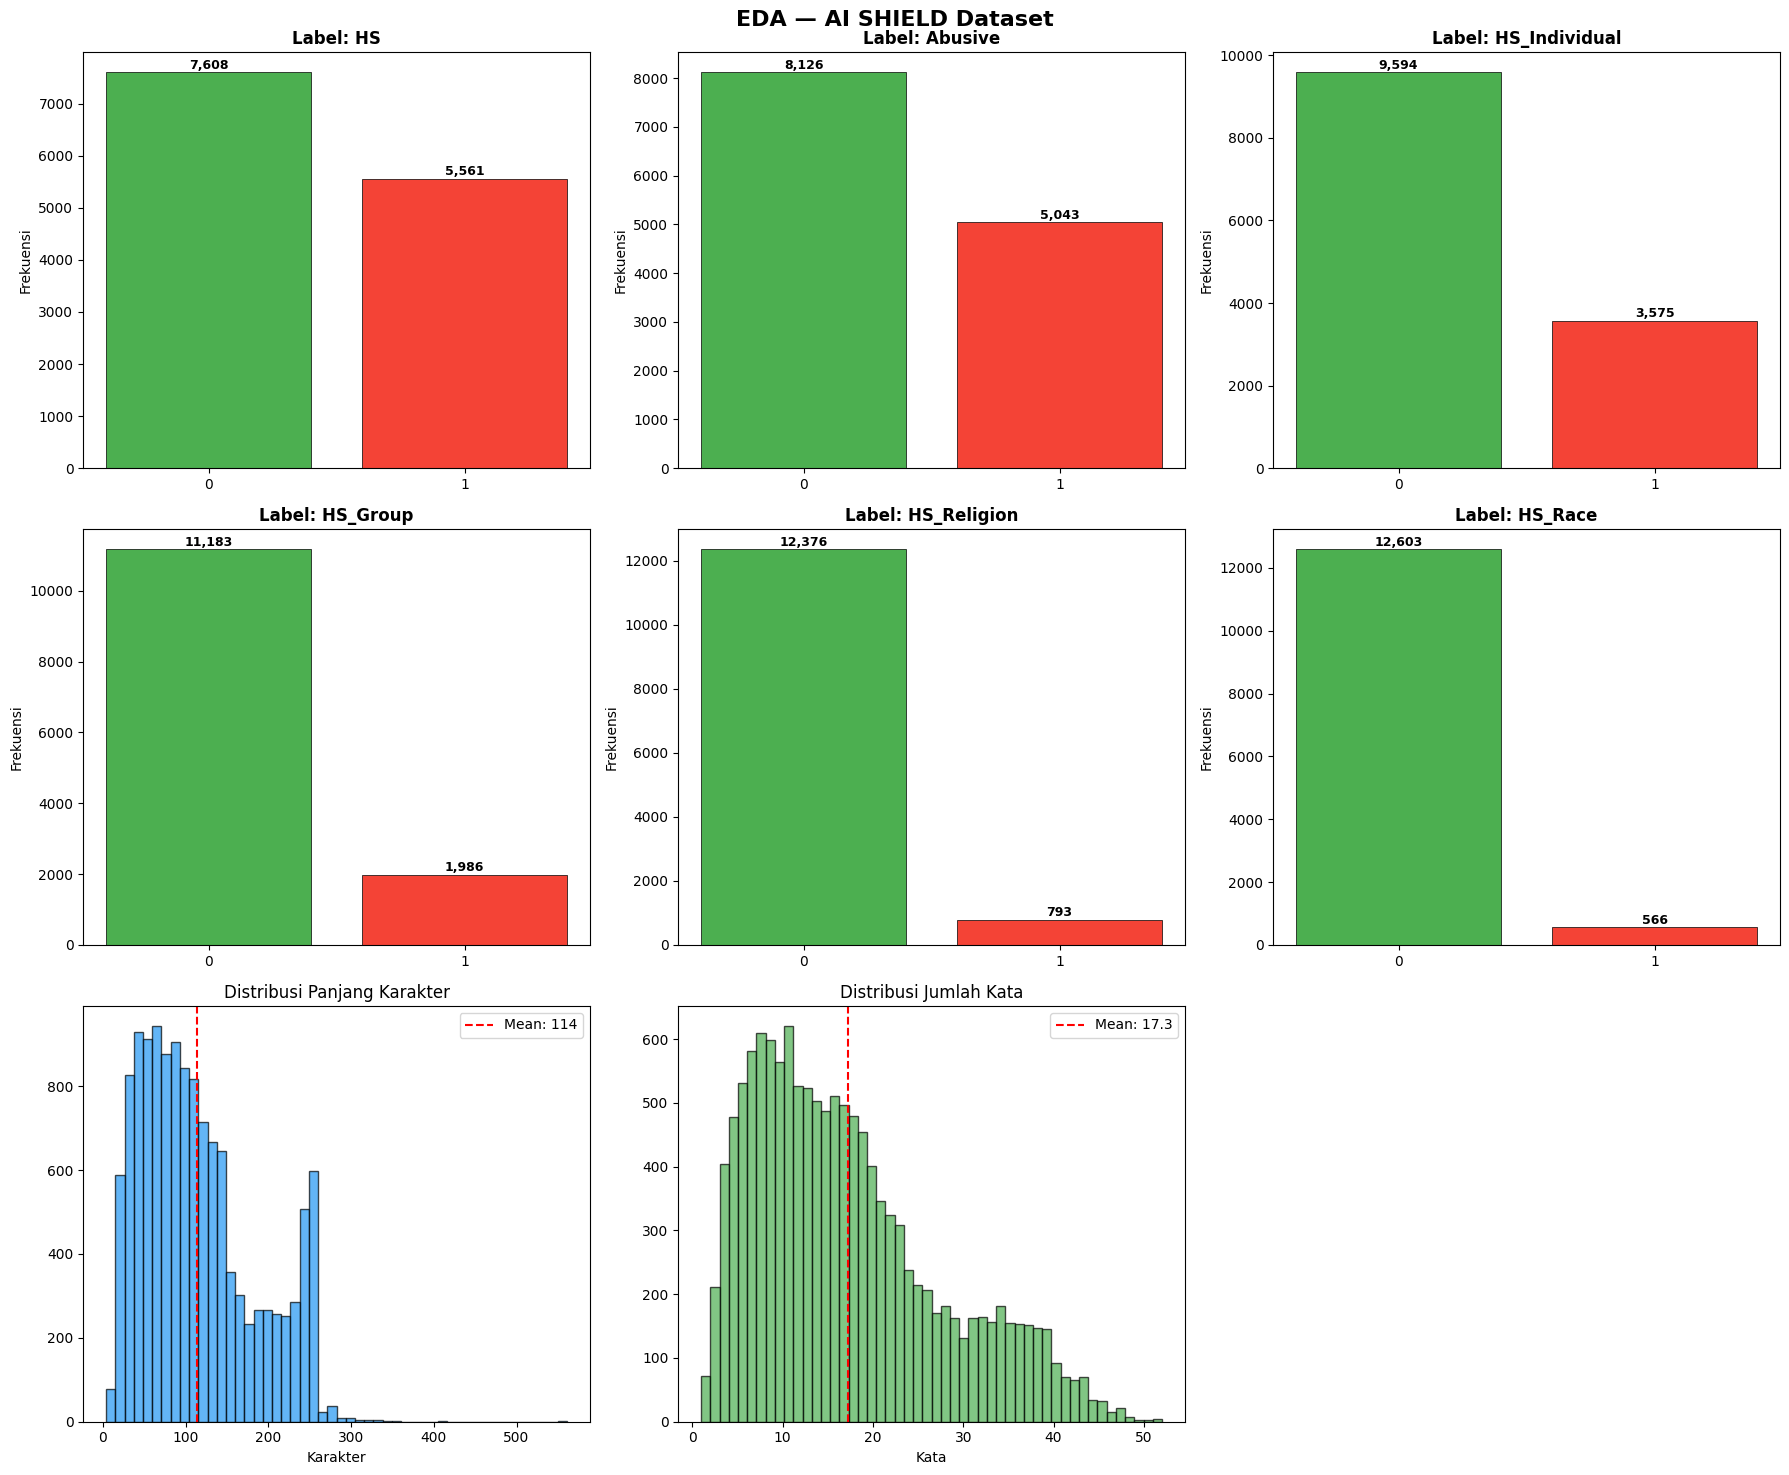


📊 Statistik Teks:
  Total data   : 13,169
  Panjang char : min=4, max=561, mean=114.2
  Jumlah kata  : min=1, max=52, mean=17.3
  P95 kata     : 38 → max_length=128 sudah cukup ✅

  HS=0 (non-hate) : 7,608 (57.8%)
  HS=1 (hate)     : 5,561 (42.2%)

✅ EDA selesai!


In [23]:
# ============================================================
# LANGKAH 2: EDA — Distribusi label & panjang teks
# ============================================================

# --- Identifikasi kolom teks secara otomatis ---
text_col = None
for col in df_raw.columns:
    if df_raw[col].dtype == object:
        avg_len = df_raw[col].dropna().astype(str).str.len().mean()
        if avg_len > 20:
            text_col = col
            break
if text_col is None:
    text_col = df_raw.columns[0]

label_cols = [c for c in df_raw.columns if c != text_col]
print(f"✅ Kolom teks  : '{text_col}'")
print(f"✅ Kolom label : {label_cols}")

# Drop baris teks kosong
df_raw = df_raw.dropna(subset=[text_col]).reset_index(drop=True)
df_raw[text_col] = df_raw[text_col].astype(str)
df_raw['char_length'] = df_raw[text_col].str.len()
df_raw['word_count']  = df_raw[text_col].str.split().str.len()

# --- Plot ---
n_cols = min(6, len(label_cols))
n_rows = (n_cols // 3) + (1 if n_cols % 3 else 0)
fig, axes = plt.subplots(n_rows + 1, 3, figsize=(18, 5 * (n_rows + 1)))
fig.suptitle('EDA — AI SHIELD Dataset', fontsize=16, fontweight='bold')
axes = axes.flatten()

colors = ['#4CAF50','#f44336','#2196F3','#FF9800','#9C27B0','#00BCD4']
for idx, col in enumerate(label_cols[:n_cols]):
    counts = df_raw[col].value_counts()
    bars = axes[idx].bar(counts.index.astype(str), counts.values,
                         color=colors[:len(counts)], edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'Label: {col}', fontweight='bold')
    axes[idx].set_ylabel('Frekuensi')
    for bar in bars:
        axes[idx].text(bar.get_x() + bar.get_width()/2.,
                       bar.get_height() + 5, f'{bar.get_height():,}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')

# Histogram panjang karakter
axes[n_cols].hist(df_raw['char_length'], bins=50, color='#2196F3', alpha=0.7, edgecolor='black')
axes[n_cols].axvline(df_raw['char_length'].mean(), color='red', linestyle='--',
                     label=f"Mean: {df_raw['char_length'].mean():.0f}")
axes[n_cols].set_title('Distribusi Panjang Karakter')
axes[n_cols].set_xlabel('Karakter')
axes[n_cols].legend()

# Histogram jumlah kata
axes[n_cols+1].hist(df_raw['word_count'], bins=50, color='#4CAF50', alpha=0.7, edgecolor='black')
axes[n_cols+1].axvline(df_raw['word_count'].mean(), color='red', linestyle='--',
                       label=f"Mean: {df_raw['word_count'].mean():.1f}")
axes[n_cols+1].set_title('Distribusi Jumlah Kata')
axes[n_cols+1].set_xlabel('Kata')
axes[n_cols+1].legend()

# Sembunyikan axes yang tidak terpakai
for ax in axes[n_cols+2:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('eda_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistik Teks:")
print(f"  Total data   : {len(df_raw):,}")
print(f"  Panjang char : min={df_raw['char_length'].min()}, max={df_raw['char_length'].max()}, mean={df_raw['char_length'].mean():.1f}")
print(f"  Jumlah kata  : min={df_raw['word_count'].min()}, max={df_raw['word_count'].max()}, mean={df_raw['word_count'].mean():.1f}")
print(f"  P95 kata     : {df_raw['word_count'].quantile(0.95):.0f} → max_length=128 sudah cukup ✅")

if 'HS' in df_raw.columns:
    dist = df_raw['HS'].value_counts()
    print(f"\n  HS=0 (non-hate) : {dist.get(0, 0):,} ({dist.get(0,0)/len(df_raw)*100:.1f}%)")
    print(f"  HS=1 (hate)     : {dist.get(1, 0):,} ({dist.get(1,0)/len(df_raw)*100:.1f}%)")
print("\n✅ EDA selesai!")

---
## 🧹 LANGKAH 3 — Preprocessing Teks

Pipeline: Lowercase → Hapus RT/Username/URL/Hashtag → Hapus emoji → Normalisasi slang → Hapus spasi

> **Tidak** dilakukan stemming/stopword removal karena IndoBERT membutuhkan teks natural.

In [24]:
# ============================================================
# LANGKAH 3: Load kamus alay & fungsi preprocessing
# ============================================================

# --- Load kamus alay ---
alay_dict = {}
for enc in ['utf-8', 'latin-1']:
    try:
        alay_df = pd.read_csv("dataset/alay_dict.csv", encoding=enc, header=None)
        alay_df = alay_df.dropna()
        alay_dict = dict(zip(
            alay_df.iloc[:, 0].astype(str).str.lower(),
            alay_df.iloc[:, 1].astype(str).str.lower()
        ))
        print(f"✅ Kamus alay dimuat: {len(alay_dict):,} kata")
        break
    except Exception:
        continue

if not alay_dict:
    # Kamus minimal fallback
    alay_dict = {
        'gak':'tidak','ga':'tidak','g':'tidak','tdk':'tidak',
        'yg':'yang','dgn':'dengan','utk':'untuk','krn':'karena',
        'sdh':'sudah','blm':'belum','lg':'lagi','jg':'juga',
        'bgt':'banget','tp':'tetapi','klo':'kalau','emg':'memang',
        'udah':'sudah','nih':'ini','tuh':'itu','enggak':'tidak',
    }
    print(f"⚠️  Kamus alay tidak ditemukan. Menggunakan kamus minimal ({len(alay_dict)} kata).")


def preprocess_text(text: str, alay_dict: dict = None) -> str:
    """
    Pipeline preprocessing teks AI SHIELD.
    Sesuai flowchart.md dan project-plan.md.
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    text = text.lower()                                   # 1. Lowercase
    text = re.sub(r'\brt\b', '', text)                    # 2. Hapus RT
    text = re.sub(r'@[\w]+', '', text)                    # 3. Hapus @username
    text = re.sub(r'http\S+|https\S+|www\.\S+', '', text) # 4. Hapus URL
    text = re.sub(r'#[\w]+', '', text)                    # 5. Hapus #hashtag
    text = text.encode('ascii', 'ignore').decode('ascii') # 6. Hapus emoji/non-ASCII
    text = re.sub(r'[^a-z0-9\s]', ' ', text)             # 7. Hapus karakter khusus
    text = re.sub(r'\b\d+\b', '', text)                   # 8. Hapus angka mandiri

    if alay_dict:                                         # 9. Normalisasi slang
        words = text.split()
        text = ' '.join(alay_dict.get(w, w) for w in words)

    text = ' '.join(text.split())                         # 10. Hapus spasi berlebih
    return text.strip()


# --- Test preprocessing ---
tests = [
    "RT @user123: Anjing banget sih lo!! http://spam.com #politik",
    "Diskusi bagus bgt makasih yg udah share 😊👍",
    "@mahasiswa dasar goblok ga punya otak!",
    "Terima kasih penjelasannya sangat informatif.",
]
print("\n🧪 Contoh preprocessing:")
for t in tests:
    p = preprocess_text(t, alay_dict)
    print(f"  IN : {t[:70]}")
    print(f"  OUT: {p}")
    print()

# --- Terapkan ke seluruh dataset ---
print("⚙️  Memproses dataset (beberapa detik)...")
df_raw['text_clean'] = df_raw[text_col].apply(lambda x: preprocess_text(x, alay_dict))
n_hapus = (df_raw['text_clean'].str.len() <= 3).sum()
df_raw = df_raw[df_raw['text_clean'].str.len() > 3].reset_index(drop=True)
print(f"✅ Selesai! {n_hapus} baris dihapus (teks kosong), sisa: {len(df_raw):,}")

⚠️  Kamus alay tidak ditemukan. Menggunakan kamus minimal (20 kata).

🧪 Contoh preprocessing:
  IN : RT @user123: Anjing banget sih lo!! http://spam.com #politik
  OUT: anjing banget sih lo

  IN : Diskusi bagus bgt makasih yg udah share 😊👍
  OUT: diskusi bagus banget makasih yang sudah share

  IN : @mahasiswa dasar goblok ga punya otak!
  OUT: dasar goblok tidak punya otak

  IN : Terima kasih penjelasannya sangat informatif.
  OUT: terima kasih penjelasannya sangat informatif

⚙️  Memproses dataset (beberapa detik)...
✅ Selesai! 1 baris dihapus (teks kosong), sisa: 13,168


---
## 🏷️ LANGKAH 4 — Relabeling (Multi-Label → Biner)

**Kebijakan Zero-Tolerance:** Jika kolom `HS` atau `Abusive` atau kolom label apapun bernilai 1 → `TIDAK PANTAS`

✅ Relabeling selesai!

📊 Distribusi Label Biner:
  TIDAK PANTAS    (1): 7,308 (55.5%) ███████████████████████████
  PANTAS          (0): 5,860 (44.5%) ██████████████████████


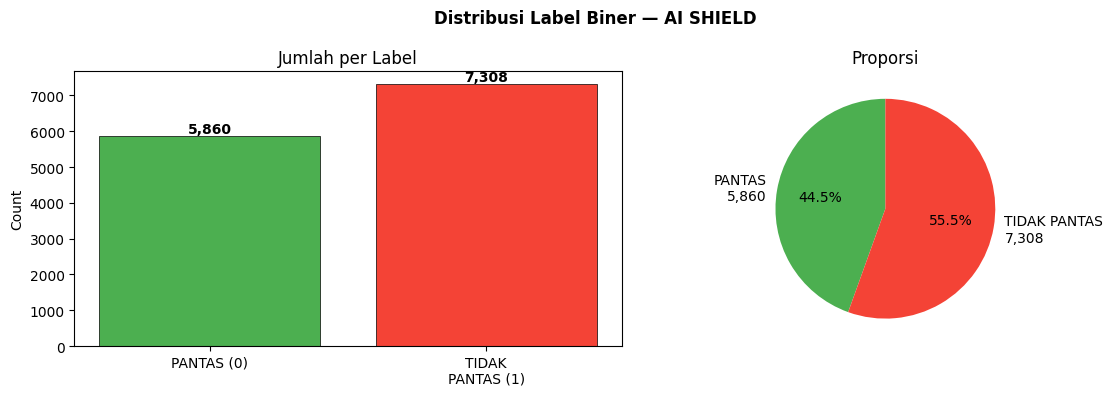


✅ Distribusi seimbang (rasio 0.8:1)


In [25]:
# ============================================================
# LANGKAH 4: Relabeling ke biner
# ============================================================

UNSAFE_COLS = [
    'HS','Abusive','HS_Individual','HS_Group',
    'HS_Religion','HS_Race','HS_Physical','HS_Gender',
    'HS_Other','HS_Weak','HS_Moderate','HS_Strong'
]

def create_binary_label(row) -> int:
    """
    Kembalikan 1 (TIDAK PANTAS) jika salah satu kolom unsafe bernilai 1.
    Kembalikan 0 (PANTAS) jika semua aman.
    """
    for col in UNSAFE_COLS:
        if col in row.index:
            try:
                if int(row[col]) == 1:
                    return 1
            except (ValueError, TypeError):
                pass
    return 0

df_raw['label']      = df_raw.apply(create_binary_label, axis=1)
df_raw['label_text'] = df_raw['label'].map({0: 'PANTAS', 1: 'TIDAK PANTAS'})

dist   = df_raw['label'].value_counts()
total  = len(df_raw)

print("✅ Relabeling selesai!\n")
print("📊 Distribusi Label Biner:")
for v, c in dist.items():
    name = 'PANTAS' if v == 0 else 'TIDAK PANTAS'
    pct  = c / total * 100
    bar  = '█' * int(pct / 2)
    print(f"  {name:15s} ({v}): {c:,} ({pct:.1f}%) {bar}")

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Label Biner — AI SHIELD', fontweight='bold')

clrs = ['#4CAF50', '#f44336']
vals = [dist.get(0, 0), dist.get(1, 0)]
labs = ['PANTAS (0)', 'TIDAK\nPANTAS (1)']

bars = ax1.bar(labs, vals, color=clrs, edgecolor='black', linewidth=0.5)
ax1.set_title('Jumlah per Label')
ax1.set_ylabel('Count')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2.,
             bar.get_height() + 20, f'{bar.get_height():,}',
             ha='center', va='bottom', fontweight='bold')

ax2.pie(vals, labels=[f'PANTAS\n{vals[0]:,}', f'TIDAK PANTAS\n{vals[1]:,}'],
        colors=clrs, autopct='%1.1f%%', startangle=90)
ax2.set_title('Proporsi')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = dist.get(0, 1) / max(dist.get(1, 1), 1)
if ratio > 3 or ratio < 0.33:
    print(f"\n⚠️  Class imbalance (rasio {ratio:.1f}:1) — pertimbangkan class_weight='balanced'")
else:
    print(f"\n✅ Distribusi seimbang (rasio {ratio:.1f}:1)")

---
## ✂️ LANGKAH 5 — Split Dataset (Stratified 70/15/15)

In [26]:
# ============================================================
# LANGKAH 5: Stratified split 70/15/15
# ============================================================

df_model = df_raw[['text_clean', 'label']].dropna().reset_index(drop=True)
X = df_model['text_clean'].values
y = df_model['label'].values

# Split 1: 70% train vs 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
# Split 2: 15% val + 15% test dari temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("✅ Split dataset selesai:\n")
print(f"  {'Split':<20} {'Total':>7} {'PANTAS':>10} {'TIDAK PANTAS':>14}")
print("  " + "-" * 55)
for name, Xs, ys in [
    ('Train (70%)', X_train, y_train),
    ('Validation (15%)', X_val, y_val),
    ('Test (15%)', X_test, y_test)
]:
    n  = len(ys)
    p  = (ys == 0).sum()
    tp = (ys == 1).sum()
    print(f"  {name:<20} {n:>7,} {p:>6,} ({p/n*100:.1f}%) {tp:>6,} ({tp/n*100:.1f}%)")

print(f"\n  Total: {len(df_model):,} sampel")
print("\n✅ Proporsi label terjaga di semua split (stratified)!")

✅ Split dataset selesai:

  Split                  Total     PANTAS   TIDAK PANTAS
  -------------------------------------------------------
  Train (70%)            9,217  4,102 (44.5%)  5,115 (55.5%)
  Validation (15%)       1,975    879 (44.5%)  1,096 (55.5%)
  Test (15%)             1,976    879 (44.5%)  1,097 (55.5%)

  Total: 13,168 sampel

✅ Proporsi label terjaga di semua split (stratified)!


---
## 🤖 LANGKAH 6 — Fine-tuning IndoBERT

Model: `indobenchmark/indobert-base-p1` (BERT base, 12 layer, 111M parameter)  
Framework: PyTorch + HuggingFace Trainer · Learning rate: 2e-5 · Epochs: 5 + early stopping

In [27]:
# ============================================================
# LANGKAH 6A: Load tokenizer IndoBERT
# ============================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128

print(f"⬇️  Memuat tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer siap — vocab size: {tokenizer.vocab_size:,}")

# Test tokenisasi
sample = "Diskusi yang sangat menarik dan informatif"
enc = tokenizer(sample, return_tensors='pt')
print(f"\n🧪 Contoh tokenisasi:")
print(f"  Input  : {sample}")
print(f"  Tokens : {tokenizer.convert_ids_to_tokens(enc['input_ids'][0])}")
print(f"  Panjang: {enc['input_ids'].shape[1]} token")

⬇️  Memuat tokenizer: indobenchmark/indobert-base-p1


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer siap — vocab size: 30,521

🧪 Contoh tokenisasi:
  Input  : Diskusi yang sangat menarik dan informatif
  Tokens : ['[CLS]', '[UNK]', 'yang', 'sangat', 'menarik', 'dan', 'informatif', '[SEP]']
  Panjang: 8 token


In [28]:
# ============================================================
# LANGKAH 6B: PyTorch Dataset class
# ============================================================

class AIShieldDataset(Dataset):
    """Dataset PyTorch untuk fine-tuning IndoBERT AI SHIELD."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }


train_dataset = AIShieldDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = AIShieldDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = AIShieldDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

print("✅ Dataset PyTorch siap:")
print(f"  Train      : {len(train_dataset):,}")
print(f"  Validation : {len(val_dataset):,}")
print(f"  Test       : {len(test_dataset):,}")

s = train_dataset[0]
print(f"\n  Sample shape  — input_ids: {s['input_ids'].shape}, label: {s['labels'].item()}")

✅ Dataset PyTorch siap:
  Train      : 9,217
  Validation : 1,975
  Test       : 1,976

  Sample shape  — input_ids: torch.Size([128]), label: 0


In [29]:
# ============================================================
# LANGKAH 6C: Load model IndoBERT
# ============================================================

id2label = {0: "PANTAS", 1: "TIDAK PANTAS"}
label2id = {"PANTAS": 0, "TIDAK PANTAS": 1}

print(f"⬇️  Memuat model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)
model = model.to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model siap — {total_p/1e6:.1f}M params total, {trainable_p/1e6:.1f}M trainable")
print(f"   Device: {next(model.parameters()).device}")

⬇️  Memuat model: indobenchmark/indobert-base-p1


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model siap — 124.4M params total, 124.4M trainable
   Device: cuda:0


In [30]:
# ============================================================
# LANGKAH 6D: Fungsi metrik evaluasi
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)

    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1], zero_division=0
    )
    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )

    return {
        'accuracy'              : acc,
        'f1_macro'              : f1_mac,
        'f1_pantas'             : f1_cls[0],
        'f1_tidak_pantas'       : f1_cls[1],
        'precision_tidak_pantas': p_cls[1],
        'recall_tidak_pantas'   : r_cls[1],
    }

print("✅ Fungsi compute_metrics siap.")

✅ Fungsi compute_metrics siap.


In [37]:
!pip install -U transformers accelerate

In [38]:
# ============================================================
# LANGKAH 6E: TrainingArguments & Trainer
# ============================================================

BATCH_SIZE = 16
NUM_EPOCHS = 5

steps_per_epoch = max(1, len(train_dataset) // BATCH_SIZE)
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)

print("📊 Konfigurasi Training:")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Total Steps  : {total_steps}")
print(f"Warmup Steps : {warmup_steps}")

training_args = TrainingArguments(
    output_dir="./ai_shield_checkpoints",

    num_train_epochs=NUM_EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,

    learning_rate=2e-5,
    weight_decay=0.01,

    warmup_steps=warmup_steps,

    save_steps=500,
    logging_steps=50,

    fp16=torch.cuda.is_available(),

    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("✅ Trainer berhasil dibuat")

📊 Konfigurasi Training:
Batch Size   : 16
Epochs       : 5
Total Steps  : 2880
Warmup Steps : 288
✅ Trainer berhasil dibuat


In [39]:
# ============================================================
# LANGKAH 6F: Jalankan training
# ============================================================

print("🚀 Mulai fine-tuning IndoBERT...")
print(f"   Estimasi: 20–60 menit (GPU T4)")
print(f"   Early stopping aktif (patience=2)\n")

train_result = trainer.train()

print("\n✅ Training selesai!")
print(f"   Waktu   : {train_result.metrics.get('train_runtime', 0):.0f} detik")
print(f"   Loss    : {train_result.metrics.get('train_loss', 0):.4f}")
print(f"   Samples/s: {train_result.metrics.get('train_samples_per_second', 0):.1f}")

🚀 Mulai fine-tuning IndoBERT...
   Estimasi: 20–60 menit (GPU T4)
   Early stopping aktif (patience=2)



Step,Training Loss
50,0.672776
100,0.515641
150,0.462286
200,0.405272
250,0.388063
300,0.380097
350,0.381403
400,0.314553
450,0.308832
500,0.312598


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Training selesai!
   Waktu   : 480 detik
   Loss    : 0.1526
   Samples/s: 95.9


In [40]:
# ============================================================
# LANGKAH 6G: Plot riwayat training
# ============================================================

eval_logs = [x for x in trainer.state.log_history if 'eval_loss' in x]

if eval_logs:
    ep      = [x['epoch'] for x in eval_logs]
    e_loss  = [x.get('eval_loss', None) for x in eval_logs]
    e_acc   = [x.get('eval_accuracy', None) for x in eval_logs]
    e_f1tp  = [x.get('eval_f1_tidak_pantas', None) for x in eval_logs]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Riwayat Training — AI SHIELD IndoBERT', fontweight='bold')

    axes[0].plot(ep, e_loss, 'b-o', lw=2, label='Val Loss')
    axes[0].set_title('Validation Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    if any(v for v in e_acc if v):
        axes[1].plot(ep, e_acc, 'g-o', lw=2, label='Accuracy')
        axes[1].axhline(0.85, color='r', ls='--', alpha=0.6, label='Target 85%')
        axes[1].set_title('Validation Accuracy')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1)
        axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if any(v for v in e_f1tp if v):
        axes[2].plot(ep, e_f1tp, 'r-o', lw=2, label='F1 TIDAK PANTAS')
        axes[2].axhline(0.82, color='orange', ls='--', alpha=0.6, label='Target 82%')
        axes[2].set_title('F1 TIDAK PANTAS')
        axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1)
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grafik disimpan ke 'training_history.png'")
else:
    print("⚠️  Tidak ada log evaluasi untuk divisualisasikan.")

⚠️  Tidak ada log evaluasi untuk divisualisasikan.


---
## 📊 LANGKAH 7 — Evaluasi Model pada Test Set

In [41]:
# ============================================================
# LANGKAH 7: Evaluasi final pada test set
# ============================================================

print("📊 Mengevaluasi model pada test set...")

test_pred = trainer.predict(test_dataset)
y_pred    = np.argmax(test_pred.predictions, axis=-1)
y_true    = test_pred.label_ids

acc                              = accuracy_score(y_true, y_pred)
p_mac, r_mac, f1_mac, _         = precision_recall_fscore_support(y_true, y_pred, average='macro',   zero_division=0)
p_cls, r_cls, f1_cls, support   = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)

print()
print("=" * 62)
print("  📋 HASIL EVALUASI MODEL — AI SHIELD IndoBERT")
print("=" * 62)
print(f"  Accuracy           : {acc:.4f} ({acc*100:.2f}%) {'✅' if acc>=0.85 else '❌ target ≥85%'}")
print(f"  F1-Score (Macro)   : {f1_mac:.4f}")
print(f"  Precision (Macro)  : {p_mac:.4f}")
print(f"  Recall (Macro)     : {r_mac:.4f}")
print()
print(f"  {'Kelas':<18} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("  " + "-" * 57)
for i, name in enumerate(['PANTAS', 'TIDAK PANTAS']):
    chk = ' ✅' if (i==1 and f1_cls[i]>=0.82) else (' ❌' if i==1 else '')
    print(f"  {name:<18} {p_cls[i]:>10.4f} {r_cls[i]:>8.4f} {f1_cls[i]:>8.4f} {support[i]:>9,}{chk}")
print("=" * 62)

print("\n🎯 Evaluasi Target:")
print(f"  Accuracy ≥ 85%          : {'✅ TERCAPAI' if acc>=0.85 else '❌ BELUM'}  ({acc*100:.2f}%)")
print(f"  F1 TIDAK PANTAS ≥ 82%   : {'✅ TERCAPAI' if f1_cls[1]>=0.82 else '❌ BELUM'}  ({f1_cls[1]*100:.2f}%)")

if acc < 0.85 or f1_cls[1] < 0.82:
    print("\n💡 Saran perbaikan:")
    print("   - Tambah epoch (NUM_EPOCHS = 7)")
    print("   - Turunkan learning rate (1e-5)")
    print("   - Augmentasi data kelas TIDAK PANTAS")
    print("   - Coba indobert-large jika VRAM cukup")

📊 Mengevaluasi model pada test set...



  📋 HASIL EVALUASI MODEL — AI SHIELD IndoBERT
  Accuracy           : 0.8927 (89.27%) ✅
  F1-Score (Macro)   : 0.8910
  Precision (Macro)  : 0.8926
  Recall (Macro)     : 0.8898

  Kelas               Precision   Recall       F1   Support
  ---------------------------------------------------------
  PANTAS                 0.8919   0.8635   0.8775       879
  TIDAK PANTAS           0.8933   0.9161   0.9046     1,097 ✅

🎯 Evaluasi Target:
  Accuracy ≥ 85%          : ✅ TERCAPAI  (89.27%)
  F1 TIDAK PANTAS ≥ 82%   : ✅ TERCAPAI  (90.46%)


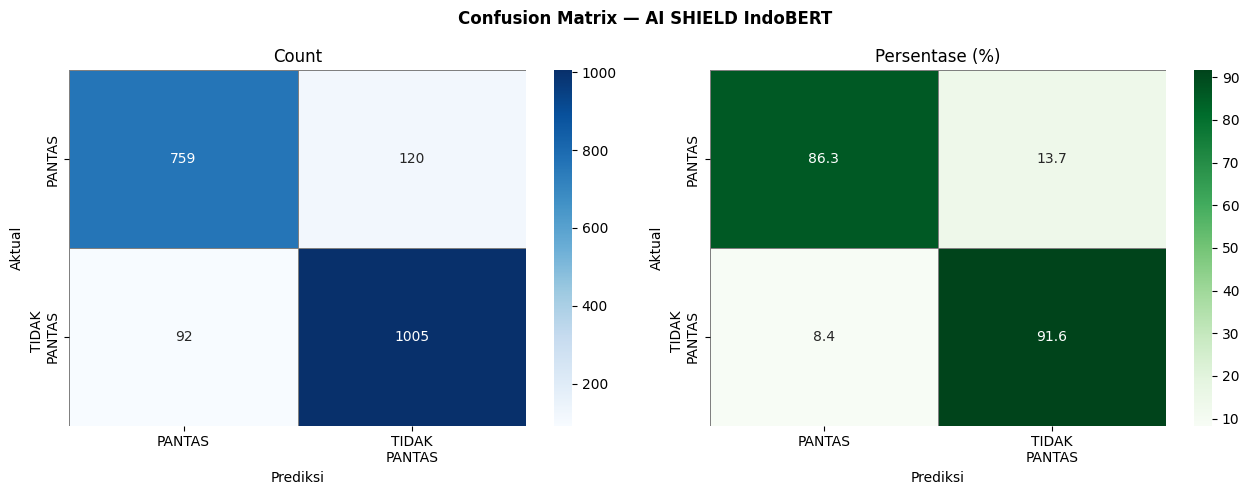


  TP=1,005  TN=759  FP=120  FN=92
  ⚠️  False Negative=92 — pesan tidak pantas yang LOLOS (berbahaya)

📋 Classification Report:
              precision    recall  f1-score   support

      PANTAS       0.89      0.86      0.88       879
TIDAK PANTAS       0.89      0.92      0.90      1097

    accuracy                           0.89      1976
   macro avg       0.89      0.89      0.89      1976
weighted avg       0.89      0.89      0.89      1976



In [42]:
# ============================================================
# LANGKAH 7B: Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — AI SHIELD IndoBERT', fontweight='bold')

labels_cm = ['PANTAS', 'TIDAK\nPANTAS']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=ax1,
            linewidths=0.5, linecolor='gray')
ax1.set_title('Count'); ax1.set_xlabel('Prediksi'); ax1.set_ylabel('Aktual')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=ax2,
            linewidths=0.5, linecolor='gray')
ax2.set_title('Persentase (%)'); ax2.set_xlabel('Prediksi'); ax2.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}")
print(f"  ⚠️  False Negative={fn:,} — pesan tidak pantas yang LOLOS (berbahaya)")

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['PANTAS', 'TIDAK PANTAS']))

---
## 🎯 LANGKAH 8 — Kalibrasi Confidence Threshold

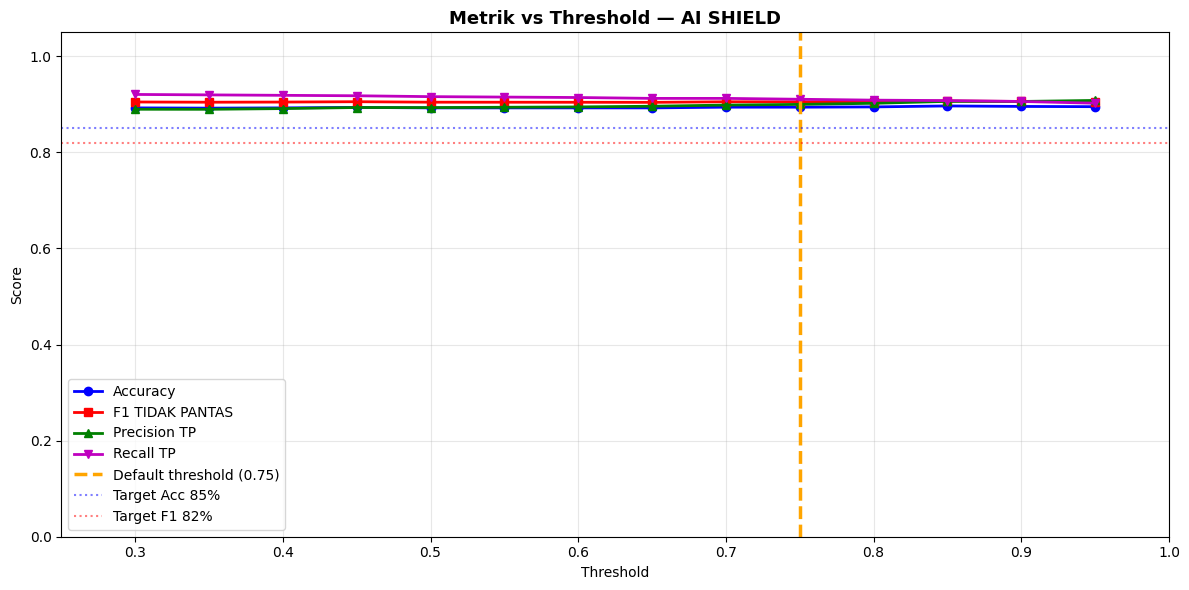


🎯 Threshold yang digunakan: 0.75
   Accuracy         : 0.8942
   F1 TIDAK PANTAS  : 0.9053
   Precision TP     : 0.9000
   Recall TP        : 0.9107

💡 Threshold optimal (F1 max): 0.85
✅ Default 0.75 dipilih untuk kebijakan konservatif lingkungan akademik


In [43]:
# ============================================================
# LANGKAH 8: Analisis threshold vs metrik
# ============================================================

logits_t = torch.tensor(test_pred.predictions)
probs    = F.softmax(logits_t, dim=-1).numpy()
prob_tp  = probs[:, 1]   # Probabilitas TIDAK PANTAS

thresholds = np.arange(0.30, 0.96, 0.05)
rows = []
for thr in thresholds:
    pred_t = (prob_tp >= thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, pred_t, average=None, labels=[0,1], zero_division=0)
    rows.append({'threshold': round(float(thr), 2),
                 'accuracy' : accuracy_score(y_true, pred_t),
                 'f1_tidak_pantas' : f1[1],
                 'precision_tp'    : p[1],
                 'recall_tp'       : r[1]})

df_thr = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_thr['threshold'], df_thr['accuracy'],        'b-o', lw=2, label='Accuracy')
ax.plot(df_thr['threshold'], df_thr['f1_tidak_pantas'], 'r-s', lw=2, label='F1 TIDAK PANTAS')
ax.plot(df_thr['threshold'], df_thr['precision_tp'],    'g-^', lw=2, label='Precision TP')
ax.plot(df_thr['threshold'], df_thr['recall_tp'],       'm-v', lw=2, label='Recall TP')
ax.axvline(0.75, color='orange', ls='--', lw=2.5, label='Default threshold (0.75)')
ax.axhline(0.85, color='blue',   ls=':',  alpha=0.5, label='Target Acc 85%')
ax.axhline(0.82, color='red',    ls=':',  alpha=0.5, label='Target F1 82%')
ax.set_title('Metrik vs Threshold — AI SHIELD', fontsize=13, fontweight='bold')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.legend(loc='lower left'); ax.grid(True, alpha=0.3)
ax.set_xlim(0.25, 1.0); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

CONFIDENCE_THRESHOLD = 0.75
row_075 = df_thr[df_thr['threshold'] == 0.75].iloc[0]
print(f"\n🎯 Threshold yang digunakan: {CONFIDENCE_THRESHOLD}")
print(f"   Accuracy         : {row_075['accuracy']:.4f}")
print(f"   F1 TIDAK PANTAS  : {row_075['f1_tidak_pantas']:.4f}")
print(f"   Precision TP     : {row_075['precision_tp']:.4f}")
print(f"   Recall TP        : {row_075['recall_tp']:.4f}")

opt_idx = df_thr['f1_tidak_pantas'].idxmax()
print(f"\n💡 Threshold optimal (F1 max): {df_thr.iloc[opt_idx]['threshold']}")
print(f"✅ Default 0.75 dipilih untuk kebijakan konservatif lingkungan akademik")

---
## 🔧 LANGKAH 9 — Inference Function

Interface identik dengan `classifier.py` di Backend — penggantian **seamless** tanpa ubah kode Backend.

In [44]:
# ============================================================
# LANGKAH 9: Fungsi predict() — interface resmi AI SHIELD
# ============================================================

model.eval()

def predict(text: str, threshold: float = 0.75) -> dict:
    """
    Klasifikasikan teks ke PANTAS atau TIDAK PANTAS.

    Interface ini identik dengan classifier.py (placeholder backend)
    sehingga penggantian bisa dilakukan tanpa mengubah kode backend.

    Args:
        text (str)       : Teks pesan dari pengguna (belum dipreprocess)
        threshold (float): Confidence threshold (default: 0.75)

    Returns:
        dict: {
          'label'              : 'PANTAS' | 'TIDAK PANTAS',
          'confidence'         : float (0.0–1.0),
          'prob_pantas'        : float,
          'prob_tidak_pantas'  : float
        }
    """
    text_clean = preprocess_text(text, alay_dict)
    if not text_clean:
        return {'label': 'PANTAS', 'confidence': 0.5,
                'prob_pantas': 0.5, 'prob_tidak_pantas': 0.5}

    inputs = tokenizer(
        text_clean,
        return_tensors='pt',
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out    = model(**inputs)
        probs  = F.softmax(out.logits, dim=-1).squeeze().cpu().numpy()

    prob_p  = float(probs[0])
    prob_tp = float(probs[1])

    if prob_tp >= threshold:
        label      = 'TIDAK PANTAS'
        confidence = prob_tp
    else:
        label      = 'PANTAS'
        confidence = prob_p

    return {
        'label'             : label,
        'confidence'        : round(confidence, 4),
        'prob_pantas'       : round(prob_p, 4),
        'prob_tidak_pantas' : round(prob_tp, 4)
    }


# --- Uji ---
test_messages = [
    # PANTAS
    "Selamat pagi, ada yang mau diskusi materi ujian?",
    "Terima kasih penjelasannya sangat membantu!",
    "Bagaimana cara implementasi rekursif di Python?",
    # TIDAK PANTAS
    "Anjing banget sih, ga ngerti-ngerti juga lo!",
    "Dasar bodoh, mending ga usah masuk kuliah!",
    "Goblok lo semua, otaknya isi apa?",
    # Ambigu
    "Wah anjir, presentasinya keren banget!",
    "Serius dah ini susah banget materinya...",
]

print("🧪 Uji Inference Function:")
print("=" * 78)
print(f"{'Pesan':<43} {'Label':<14} {'Conf':>6} {'P(TP)':>7}")
print("-" * 78)
for msg in test_messages:
    r   = predict(msg)
    ico = '🟢' if r['label'] == 'PANTAS' else '🔴'
    print(f"{ico} {msg[:41]:<41} {r['label']:<14} {r['confidence']:>6.4f} {r['prob_tidak_pantas']:>7.4f}")
print("=" * 78)
print(f"\n✅ Fungsi predict() siap digunakan Backend Engineer!")

🧪 Uji Inference Function:
Pesan                                       Label            Conf   P(TP)
------------------------------------------------------------------------------
🟢 Selamat pagi, ada yang mau diskusi materi PANTAS         0.9999  0.0001
🟢 Terima kasih penjelasannya sangat membant PANTAS         0.9959  0.0041
🟢 Bagaimana cara implementasi rekursif di P PANTAS         0.9998  0.0002
🔴 Anjing banget sih, ga ngerti-ngerti juga  TIDAK PANTAS   0.9998  0.9998
🔴 Dasar bodoh, mending ga usah masuk kuliah TIDAK PANTAS   0.9998  0.9998
🔴 Goblok lo semua, otaknya isi apa?         TIDAK PANTAS   0.9998  0.9998
🔴 Wah anjir, presentasinya keren banget!    TIDAK PANTAS   0.9998  0.9998
🔴 Serius dah ini susah banget materinya...  TIDAK PANTAS   0.9997  0.9997

✅ Fungsi predict() siap digunakan Backend Engineer!


---
## 💾 LANGKAH 10 — Simpan Model & Upload Google Drive

In [45]:
# ============================================================
# LANGKAH 10A: Simpan model ke disk
# ============================================================

MODEL_SAVE_PATH = "./ai_shield_indobert_model"
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

metadata = {
    "model_name"           : "AI SHIELD IndoBERT",
    "base_model"           : MODEL_NAME,
    "task"                 : "binary-text-classification",
    "labels"               : {"0": "PANTAS", "1": "TIDAK PANTAS"},
    "confidence_threshold" : CONFIDENCE_THRESHOLD,
    "max_length"           : MAX_LENGTH,
    "evaluation_metrics"   : {
        "accuracy"              : round(float(acc), 4),
        "f1_macro"              : round(float(f1_mac), 4),
        "f1_pantas"             : round(float(f1_cls[0]), 4),
        "f1_tidak_pantas"       : round(float(f1_cls[1]), 4),
        "precision_tidak_pantas": round(float(p_cls[1]), 4),
        "recall_tidak_pantas"   : round(float(r_cls[1]), 4),
    },
    "training_config"      : {
        "learning_rate" : 2e-5,
        "batch_size"    : BATCH_SIZE,
        "num_epochs"    : NUM_EPOCHS,
        "seed"          : SEED
    },
    "dataset"              : {
        "source"        : "https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection",
        "total_samples" : len(df_model),
        "split_ratio"   : "70/15/15"
    },
    "project"              : "AI SHIELD — PIJAK x IBM SkillsBuild"
}

with open(f"{MODEL_SAVE_PATH}/model_metadata.json", 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

files      = os.listdir(MODEL_SAVE_PATH)
total_mb   = sum(os.path.getsize(f"{MODEL_SAVE_PATH}/{fn}") for fn in files) / (1024**2)
print(f"✅ Model disimpan ke: {MODEL_SAVE_PATH}")
print(f"   Files     : {files}")
print(f"   Total size: {total_mb:.1f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model disimpan ke: ./ai_shield_indobert_model
   Files     : ['model_metadata.json', 'tokenizer.json', 'model.safetensors', 'training_args.bin', 'config.json', 'tokenizer_config.json']
   Total size: 475.4 MB


In [47]:
# ============================================================
# LANGKAH 10B: Upload ke Google Drive
# ============================================================

from google.colab import drive
import shutil

drive.mount('/content/drive')

GDRIVE_MODEL  = "/content/drive/MyDrive/AI_SHIELD/model"
GDRIVE_ASSETS = "/content/drive/MyDrive/AI_SHIELD/assets"
os.makedirs(GDRIVE_MODEL, exist_ok=True)
os.makedirs(GDRIVE_ASSETS, exist_ok=True)

# Copy model files
print("📤 Upload model...")
for fn in os.listdir(MODEL_SAVE_PATH):
    src = f"{MODEL_SAVE_PATH}/{fn}"
    dst = f"{GDRIVE_MODEL}/{fn}"
    shutil.copy2(src, dst)
    size = os.path.getsize(dst) / (1024**2)
    print(f"   ✅ {fn} ({size:.1f} MB)")

# Copy aset visualisasi
print("\n📤 Upload aset visualisasi...")
for img in ['eda_results.png','label_distribution.png',
            'training_history.png','confusion_matrix.png','threshold_calibration.png']:
    if os.path.exists(img):
        shutil.copy2(img, f"{GDRIVE_ASSETS}/{img}")
        print(f"   ✅ {img}")

print(f"\n✅ Upload selesai!")
print(f"   Model path Google Drive: {GDRIVE_MODEL}")
print(f"   Cantumkan path ini di README.md untuk Backend Engineer")

Mounted at /content/drive
📤 Upload model...
   ✅ model_metadata.json (0.0 MB)
   ✅ tokenizer.json (0.7 MB)
   ✅ model.safetensors (474.7 MB)
   ✅ training_args.bin (0.0 MB)
   ✅ config.json (0.0 MB)
   ✅ tokenizer_config.json (0.0 MB)

📤 Upload aset visualisasi...
   ✅ eda_results.png
   ✅ label_distribution.png
   ✅ confusion_matrix.png
   ✅ threshold_calibration.png

✅ Upload selesai!
   Model path Google Drive: /content/drive/MyDrive/AI_SHIELD/model
   Cantumkan path ini di README.md untuk Backend Engineer


In [ ]:
# ============================================================
# LANGKAH 10C: Verifikasi model yang disimpan
# ============================================================

print("🔍 Verifikasi — memuat ulang model dari disk...")

tok_v   = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)
model_v = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_PATH).to(device)
model_v.eval()

def predict_loaded(text, model_obj, tok_obj, threshold=0.75):
    clean  = preprocess_text(text, alay_dict)
    inputs = tok_obj(clean, return_tensors='pt', max_length=MAX_LENGTH,
                     padding='max_length', truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        probs = F.softmax(model_obj(**inputs).logits, dim=-1).squeeze().cpu().numpy()
    label = 'TIDAK PANTAS' if probs[1] >= threshold else 'PANTAS'
    return {'label': label, 'confidence': round(float(max(probs)), 4)}

verify = [
    "Selamat pagi, bagaimana kabar hari ini?",
    "Dasar bodoh, ga ada gunanya!",
]

print("\n🧪 Verifikasi inference dari model yang disimpan:")
for t in verify:
    r   = predict_loaded(t, model_v, tok_v)
    ico = '🟢' if r['label'] == 'PANTAS' else '🔴' 
    print(f"   {ico} '{t[:50]}' → {r['label']} ({r['confidence']:.4f})")

print("\n✅ Model tersimpan dan berjalan dengan benar!")

🔍 Verifikasi — memuat ulang model dari disk...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


🧪 Verifikasi inference dari model yang disimpan:
   🟢 'Selamat pagi, bagaimana kabar hari ini?' → PANTAS (0.9995)
   🔴 'Dasar bodoh, ga ada gunanya!' → TIDAK PANTAS (0.9998)

✅ Model tersimpan dan berjalan dengan benar!


---
## 🏁 RINGKASAN AKHIR

| Langkah | Status |
|---------|--------|
| 0 Setup Environment | ✅ |
| 1 Download Dataset (okkyibrohim) | ✅ |
| 2 EDA | ✅ |
| 3 Preprocessing Teks | ✅ |
| 4 Relabeling → Biner | ✅ |
| 5 Split 70/15/15 Stratified | ✅ |
| 6 Fine-tuning IndoBERT | ✅ |
| 7 Evaluasi (Accuracy, F1, CM) | ✅ |
| 8 Kalibrasi Threshold (0.75) | ✅ |
| 9 Fungsi `predict(text)` | ✅ |
| 10 Simpan & Upload Google Drive | ✅ |

### Cara pakai model untuk Backend Engineer
```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
model     = AutoModelForSequenceClassification.from_pretrained("/path/model")
tokenizer = AutoTokenizer.from_pretrained("/path/model")

# Atau langsung panggil:
result = predict("teks pesan pengguna")
# {'label': 'PANTAS'|'TIDAK PANTAS', 'confidence': 0.0–1.0}
```

---
*AI SHIELD — PIJAK × IBM SkillsBuild × Dicoding*

In [49]:
# ============================================================
# Cetak ringkasan metrik akhir
# ============================================================

print("=" * 65)
print("  🛡️  AI SHIELD — RINGKASAN HASIL")
print("=" * 65)
print(f"  Model        : {MODEL_NAME}")
print(f"  Dataset      : okkyibrohim/id-multi-label-hate-speech")
print(f"  Total sampel : {len(df_model):,} tweet")
print(f"  Split        : 70/15/15 (stratified)")
print()
print(f"  Accuracy          : {acc:.4f} ({acc*100:.2f}%) {'✅' if acc>=0.85 else '❌'}")
print(f"  F1-Score Macro    : {f1_mac:.4f}")
print(f"  F1 TIDAK PANTAS   : {f1_cls[1]:.4f} ({f1_cls[1]*100:.2f}%) {'✅' if f1_cls[1]>=0.82 else '❌'}")
print(f"  Precision TP      : {p_cls[1]:.4f}")
print(f"  Recall TP         : {r_cls[1]:.4f}")
print()
print(f"  Threshold         : {CONFIDENCE_THRESHOLD}")
print(f"  Model path        : {MODEL_SAVE_PATH}")
print()
print("  TARGET:")
print(f"  Accuracy ≥ 85%   : {'✅ TERCAPAI' if acc>=0.85 else '❌ BELUM'}")
print(f"  F1 TP ≥ 82%      : {'✅ TERCAPAI' if f1_cls[1]>=0.82 else '❌ BELUM'}")
print("=" * 65)
print("  Model siap digunakan Backend Engineer! 🚀")
print("=" * 65)

  🛡️  AI SHIELD — RINGKASAN HASIL
  Model        : indobenchmark/indobert-base-p1
  Dataset      : okkyibrohim/id-multi-label-hate-speech
  Total sampel : 13,168 tweet
  Split        : 70/15/15 (stratified)

  Accuracy          : 0.8927 (89.27%) ✅
  F1-Score Macro    : 0.8910
  F1 TIDAK PANTAS   : 0.9046 (90.46%) ✅
  Precision TP      : 0.8933
  Recall TP         : 0.9161

  Threshold         : 0.75
  Model path        : ./ai_shield_indobert_model

  TARGET:
  Accuracy ≥ 85%   : ✅ TERCAPAI
  F1 TP ≥ 82%      : ✅ TERCAPAI
  Model siap digunakan Backend Engineer! 🚀
